In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [2]:
df=pd.read_pickle("soundfeature_other.pkl")

In [3]:
df.columns

Index(['Date', 'place', 'level', 'ZCR', 'MEANt', 'VARt', 'SKEWt', 'KURTt',
       'LEQt', 'BGNt', 'SNRt', 'MED', 'Ht', 'ACTtFraction', 'ACTtCount',
       'ACTtMean', 'EVNtFraction', 'EVNtMean', 'EVNtCount', 'MEANf', 'VARf',
       'SKEWf', 'KURTf', 'NBPEAKS', 'LEQf', 'ENRf', 'BGNf', 'SNRf', 'Hf',
       'EAS', 'ECU', 'ECV', 'EPS', 'EPS_KURT', 'EPS_SKEW', 'ACI', 'NDSI',
       'rBA', 'AnthroEnergy', 'BioEnergy', 'BI', 'ROU', 'ADI', 'AEI', 'LFC',
       'MFC', 'HFC', 'ACTspFract', 'ACTspCount', 'ACTspMean', 'EVNspFract',
       'EVNspMean', 'EVNspCount', 'TFSD', 'H_Havrda', 'H_Renyi',
       'H_pairedShannon', 'H_gamma', 'H_GiniSimpson', 'RAOQ', 'AGI',
       'ROItotal', 'ROIcover'],
      dtype='object')

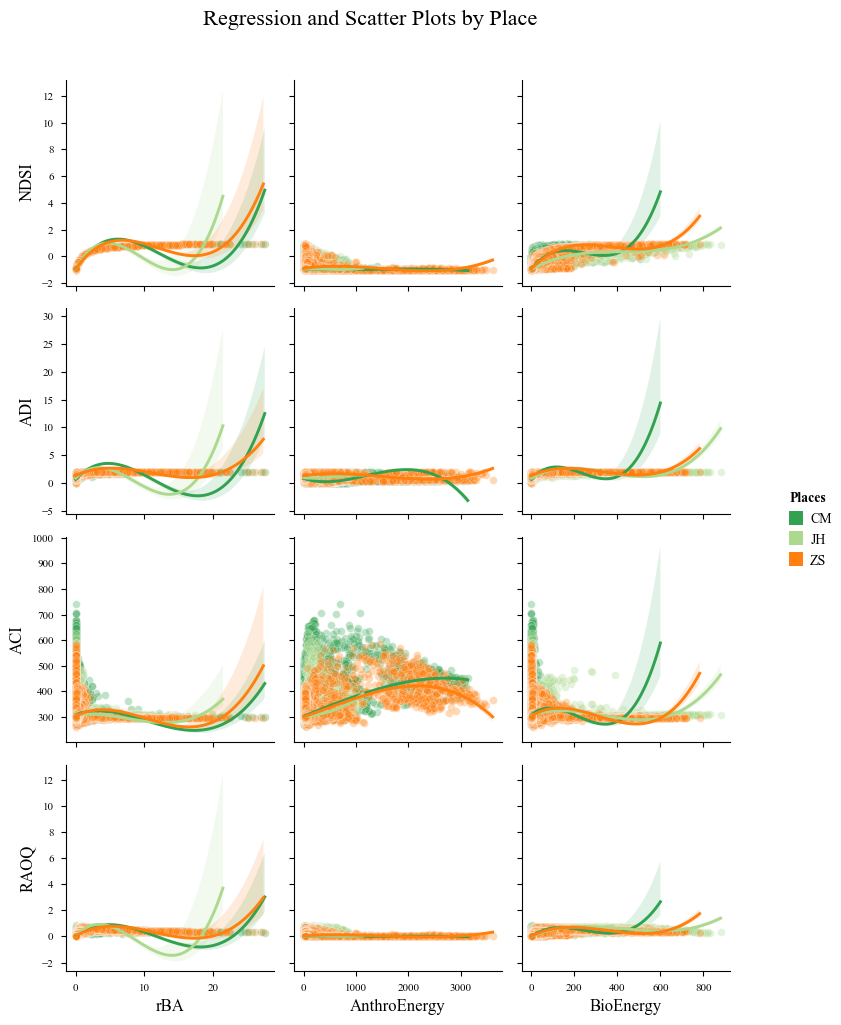

In [4]:
from legendkit import colorart, cat_legend, vstack
from palettable.tableau import GreenOrange_12

# 设置自变量和因变量
X = df[['rBA', 'AnthroEnergy', 'BioEnergy']]
Y = df[['NDSI', 'ADI', 'ACI', 'RAOQ']]

# 创建一个新的DataFrame，将X和Y组合在一起，并添加place信息
df_plot = df[['place'] + X.columns.tolist() + Y.columns.tolist()]

# 自定义调色板
palette = GreenOrange_12.mpl_colors

# 获取唯一的place和level，并按顺序排列
sorted_places = sorted(df_plot['place'].unique())

# 创建子图网格
g = sns.PairGrid(df_plot, hue='place', x_vars=X.columns, y_vars=Y.columns, palette=palette)

for i, ax in enumerate(g.axes.flatten()):
    x_var = g.x_vars[i % len(X.columns)]
    y_var = g.y_vars[i // len(X.columns)]
    
    for place, color in zip(sorted_places, palette):
        subset = df_plot[df_plot['place'] == place]
        sns.scatterplot(data=subset, x=x_var, y=y_var, ax=ax, color=color, alpha=0.3)
        sns.regplot(data=subset, x=x_var, y=y_var, scatter=False, ax=ax, color=color, order=3)
    
    ax.set_xlabel(x_var, fontsize=12)
    ax.set_ylabel(y_var, fontsize=12)

# 设置图表标题
g.fig.suptitle('Regression and Scatter Plots by Place', fontsize=16, y=1.02)

# 自定义图例
legend_args = dict(
    colors=palette,
    labels=sorted_places,
)
legend1 = cat_legend(**legend_args, title='Places', loc="out right center", frameon=False, ax=g.fig)


# 调整布局
plt.tight_layout()
plt.savefig("regression.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()